# SI 305 Final Project - Analysis Materials
**Student:** Hong Kiu Lui  
**UMID:** 32126869
---

## Research Questions

**RQ1:** Are areas in Michigan (ZIP Codes) with a higher share of houses built before 1980 more likely to have children with EBLL from 2010 to 2023? 

- **Key words to note**:
    - EBLLL Rate = Percentage of children under 6 that tested positive for EBLL
    - Percentage of pre-1980 housing = the share of older housing (pre-1980) housing 

    

**RQ2:** Are areas in Michigan (ZIP codes) with a higher share of housing built before 1980 seeing higher rates of childhood EBLL testing from 2010 to 2023?

- **Key words to note**:
    - Testing coverage rate = the share of children that test for EBLL
    - Percentage of pre-1980 housing = the share of older housing (pre-1980) housing 

    
**Note** Old housing has been determined as before 1980 since the use of lead was mostly banned in 1978. 
Additionally, Michigan enacted lead testing mandate for all in 2023, hence why the time frame is until 2023.



---
## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')


## 1.1 Load EBLL Data

In [2]:
# Load the EBLL dataset
# This contains blood lead testing results by ZIP code and year
ebll_raw = pd.read_csv('ebll.csv')

print(f"Raw EBLL data loaded: {len(ebll_raw):,} rows")
print(f"Columns: {list(ebll_raw.columns)}")
print("\nFirst few rows:")
ebll_raw.head()

Raw EBLL data loaded: 30,800 rows
Columns: ['Geographic Area(s)', 'Year(s)', 'Age Group/Status', 'Test Type', 'Blood Lead Reference Value', 'Number of Children Tested', 'Number of Children with an EBLL', 'Percent of Children Tested with an EBLL']

First few rows:


,Geographic Area(s),Year(s),Age Group/Status,Test Type,Blood Lead Reference Value,Number of Children Tested,Number of Children with an EBLL,Percent of Children Tested with an EBLL
0,48001,2010,All Children <6,All Test Types,3.5,150.0,15.0,10
1,48001,2010,All Children <6,All Test Types,5.0,150.0,9.0,6
2,48001,2011,All Children <6,All Test Types,3.5,156.0,7.0,4.5
3,48001,2011,All Children <6,All Test Types,5.0,156.0,6.0,3.8
4,48001,2012,All Children <6,All Test Types,3.5,167.0,12.0,7.2


## 1.2 Clean EBLL Data

In [3]:
# Clean the EBLL data for analysis

# Convert percentage column to numeric
# Some values are strings like "<3" or "Suppressed", so we use errors='coerce' to turn those into NaN
ebll_raw['EBLL_Pct'] = pd.to_numeric(ebll_raw['Percent of Children Tested with an EBLL'], 
                                     errors='coerce')

# Extract ZIP code and Year as clean numeric columns
ebll_raw['ZIP'] = ebll_raw['Geographic Area(s)']
ebll_raw['Year'] = ebll_raw['Year(s)']

# Filter to only reference value 3.5 (current CDC standard)
ebll = ebll_raw[ebll_raw['Blood Lead Reference Value'] == 3.5].copy()

# Remove rows with missing EBLL percentages (these are suppressed values)
ebll = ebll[ebll['EBLL_Pct'].notna()].copy()

# Focus on 2010-2023 time period
ebll = ebll[(ebll['Year'] >= 2010) & (ebll['Year'] <= 2023)].copy()

# Keep only necessary columns for cleaner dataset
ebll = ebll[['ZIP', 'Year', 'EBLL_Pct', 'Number of Children Tested', 
             'Number of Children with an EBLL']].copy()

# Rename columns for easier reference
ebll.columns = ['ZIP', 'Year', 'EBLL_Pct', 'Children_Tested', 'EBLL_Cases']

print(f" Cleaned EBLL data: {len(ebll):,} observations")
print(f"  ZIP codes: {ebll['ZIP'].nunique()}")
print(f"  Years: {ebll['Year'].min()}-{ebll['Year'].max()}")
print(f"  EBLL rate range: {ebll['EBLL_Pct'].min():.1f}% - {ebll['EBLL_Pct'].max():.1f}%")

ebll.head(10)

 Cleaned EBLL data: 8,184 observations
  ZIP codes: 1177
  Years: 2010-2023
  EBLL rate range: 0.0% - 57.1%


,ZIP,Year,EBLL_Pct,Children_Tested,EBLL_Cases
0,48001,2010,10.0,150.0,15.0
2,48001,2011,4.5,156.0,7.0
4,48001,2012,7.2,167.0,12.0
6,48001,2013,6.5,168.0,11.0
10,48001,2015,6.3,144.0,9.0
12,48001,2016,7.9,178.0,14.0
22,48001,2021,0.0,75.0,0.0
32,48002,2011,0.0,23.0,0.0
34,48002,2012,0.0,18.0,0.0
40,48002,2015,0.0,16.0,0.0


## 1.3 Load Population Data

In [4]:
# Load population data
population = pd.read_csv('population.csv', dtype={'GEO_ID': str})

print(f"Population dataset loaded: {len(population):,} rows")

# Extract ZIP codes from GEO_ID column
# GEO_ID format: "860Z200US48001" where the last 5 digits are the ZIP code
population['ZIP'] = population['GEO_ID'].str[-5:]

# CALCULATE POPULATION UNDER 6 YEARS OLD (to match EBLL data)
# Convert columns to numeric
population['Under_3'] = pd.to_numeric(population['B09001_003E'], errors='coerce')
population['Age_3_4'] = pd.to_numeric(population['B09001_004E'], errors='coerce')
population['Age_5'] = pd.to_numeric(population['B09001_005E'], errors='coerce')

# Calculate total population under 6
population['Population_Under_6'] = (
    population['Under_3'].fillna(0) + 
    population['Age_3_4'].fillna(0) + 
    population['Age_5'].fillna(0)
)

# Keep only necessary columns
population_clean = population[['ZIP', 'Population_Under_6']].copy()

# Remove any rows with missing or zero population data
population_clean = population_clean[population_clean['Population_Under_6'] > 0]

# Convert population to integer
population_clean['Population_Under_6'] = population_clean['Population_Under_6'].astype(int)

print(f"\nCleaned population data: {len(population_clean):,} ZIP codes")
print(f"Population under 6 range: {population_clean['Population_Under_6'].min():,} - "
      f"{population_clean['Population_Under_6'].max():,} children")
print(f"Mean population under 6: {population_clean['Population_Under_6'].mean():.0f} children per ZIP")

# Preview
print("\nFirst few rows:")
print(population_clean.head(10))

# Verify no missing data
print(f"\nData quality check:")
print(f"  ZIPs with valid data: {len(population_clean):,}")
print(f"  Missing/zero values: {(population_clean['Population_Under_6'] == 0).sum()}")


Population dataset loaded: 994 rows

Cleaned population data: 936 ZIP codes
Population under 6 range: 1 - 6,026 children
Mean population under 6: 710 children per ZIP

First few rows:
      ZIP  Population_Under_6
1   48001                 851
2   48002                 139
3   48003                 240
4   48005                 201
5   48006                 243
6   48009                1719
7   48014                 322
8   48015                 384
9   48017                 456
10  48021                2496

Data quality check:
  ZIPs with valid data: 936
  Missing/zero values: 0


## 1.4 Load Housing Age Data

In [5]:
# Load housing age data from Census
housing_raw = pd.read_csv('housing_age.csv')

print(f"Raw housing data loaded: {len(housing_raw):,} ZIP codes")
print(f"Columns: {len(housing_raw.columns)} columns")
print("\nFirst few rows:")
housing_raw.head()

Raw housing data loaded: 994 ZIP codes
Columns: 25 columns

First few rows:


,GEO_ID,NAME,B25034_001E,B25034_001M,B25034_002E,B25034_002M,B25034_003E,B25034_003M,B25034_004E,B25034_004M,...,B25034_007M,B25034_008E,B25034_008M,B25034_009E,B25034_009M,B25034_010E,B25034_010M,B25034_011E,B25034_011M,Unnamed: 24
0,Geography,Geographic Area Name,Estimate!!Total:,Margin of Error!!Total:,Estimate!!Total:!!Built 2020 or later,Margin of Error!!Total:!!Built 2020 or later,Estimate!!Total:!!Built 2010 to 2019,Margin of Error!!Total:!!Built 2010 to 2019,Estimate!!Total:!!Built 2000 to 2009,Margin of Error!!Total:!!Built 2000 to 2009,...,Margin of Error!!Total:!!Built 1970 to 1979,Estimate!!Total:!!Built 1960 to 1969,Margin of Error!!Total:!!Built 1960 to 1969,Estimate!!Total:!!Built 1950 to 1959,Margin of Error!!Total:!!Built 1950 to 1959,Estimate!!Total:!!Built 1940 to 1949,Margin of Error!!Total:!!Built 1940 to 1949,Estimate!!Total:!!Built 1939 or earlier,Margin of Error!!Total:!!Built 1939 or earlier,NaN
1,860Z200US48001,ZCTA5 48001,5841,209,9,14,165,92,464,134,...,248,681,158,783,145,335,113,770,174,NaN
2,860Z200US48002,ZCTA5 48002,1320,92,24,40,101,111,183,56,...,76,39,22,131,54,25,17,186,72,NaN
3,860Z200US48003,ZCTA5 48003,2328,217,50,41,192,81,334,92,...,61,185,64,186,73,17,20,397,112,NaN
4,860Z200US48005,ZCTA5 48005,1848,190,25,33,54,37,218,80,...,92,75,36,144,66,68,41,402,104,NaN


## 1.5 Process Housing Age Data


In [6]:
# Process housing age data to get % pre-1980 housing

# Step 1: Extract ZIP code from GEO_ID (format = "8600000US48001")
# We take the last 5 characters which are the ZIP code
housing_raw['ZIP'] = housing_raw['GEO_ID'].str[-5:]

# Step 2: Convert housing count columns to numeric
# The columns represent different time periods when houses were built
housing_cols = [col for col in housing_raw.columns if 'B25034' in col and 'E' in col]
for col in housing_cols:
    housing_raw[col] = pd.to_numeric(housing_raw[col], errors='coerce')

# Step 3: Calculate total housing units
housing_raw['Total_Housing'] = housing_raw['B25034_001E']

# Step 4: Calculate pre-1980 housing
pre1980_cols = [
    'B25034_007E',
    'B25034_008E',
    'B25034_009E',
    'B25034_010E',
    'B25034_011E'
]
housing_raw['Pre1980_Housing'] = housing_raw[pre1980_cols].sum(axis=1)

# Step 5: Calculate percentage of pre-1980 housing
housing_raw['Pct_Pre1980'] = (housing_raw['Pre1980_Housing'] / housing_raw['Total_Housing']) * 100

# Step 6: Keep only necessary columns
housing = housing_raw[['ZIP', 'Total_Housing', 'Pre1980_Housing', 'Pct_Pre1980']].copy()

# Step 7: Remove rows with missing data
housing = housing[housing['Pct_Pre1980'].notna()].copy()

# Step 8: Create housing age categories for subgroup analysis
# Low: <40% pre-1980 housing (newer communities)
# Medium: 40-70% pre-1980 housing
# High: >70% pre-1980 housing (older communities)
def categorize_housing(pct):
    if pct < 40:
        return 'Low (<40%)'
    elif pct < 70:
        return 'Medium (40-70%)'
    else:
        return 'High (≥70%)'

housing['Housing_Category'] = housing['Pct_Pre1980'].apply(categorize_housing)

print(f"  Processed housing data: {len(housing):,} ZIP codes")
print(f"  Pre-1980 housing % range: {housing['Pct_Pre1980'].min():.1f}% - {housing['Pct_Pre1980'].max():.1f}%")
print(f"\nHousing category distribution:")
print(housing['Housing_Category'].value_counts().sort_index())

housing.head(10)

  Processed housing data: 982 ZIP codes
  Pre-1980 housing % range: 0.0% - 100.0%

Housing category distribution:
Housing_Category
High (≥70%)        295
Low (<40%)          91
Medium (40-70%)    596
Name: count, dtype: int64


,ZIP,Total_Housing,Pre1980_Housing,Pct_Pre1980,Housing_Category
1,48001,5841.0,3748.0,64.167095,Medium (40-70%)
2,48002,1320.0,630.0,47.727273,Medium (40-70%)
3,48003,2328.0,965.0,41.451890,Medium (40-70%)
4,48005,1848.0,1058.0,57.251082,Medium (40-70%)
5,48006,1549.0,706.0,45.577792,Medium (40-70%)
6,48009,10435.0,7412.0,71.030187,High (≥70%)
7,48014,1694.0,791.0,46.694215,Medium (40-70%)
8,48015,3772.0,3345.0,88.679745,High (≥70%)
9,48017,5993.0,5200.0,86.767896,High (≥70%)
10,48021,14050.0,13365.0,95.124555,High (≥70%)


## 1.6 Merge Datasets for Analysis

In [7]:
# Merge EBLL and housing data

# Step 1: Merge datasets on ZIP code
# Keep only ZIP codes present in BOTH datasets
merged = ebll.merge(housing, on='ZIP', how='inner')

# Step 2: Apply minimum testing threshold
# Only include ZIP/year combinations with ≥10 children tested, which ensures we have reliable EBLL rate estimates
merged = merged[merged['Children_Tested'] >= 10].copy()

print(f"  Merged dataset created: {len(merged):,} observations")
print(f"  Unique ZIP codes: {merged['ZIP'].nunique()}")
print(f"  Years covered: {merged['Year'].min()}-{merged['Year'].max()}")
print(f"  Mean children tested per ZIP/year: {merged['Children_Tested'].mean():.0f}")

# Summary statistics
print("\nSummary statistics:")
merged[['EBLL_Pct', 'Pct_Pre1980', 'Children_Tested']].describe()

  Merged dataset created: 5,557 observations
  Unique ZIP codes: 838
  Years covered: 2010-2023
  Mean children tested per ZIP/year: 263

Summary statistics:


,EBLL_Pct,Pct_Pre1980,Children_Tested
count,5557.000000,5557.000000,5557.000000
mean,5.001943,64.248407,263.117150
std,6.143673,17.600561,321.921647
min,0.000000,7.504627,10.000000
25%,0.000000,51.475694,33.000000
50%,3.400000,63.504532,151.000000
75%,7.400000,76.671632,363.000000
max,57.100000,100.000000,2437.000000


<a id='rq1'></a>
---
---
# 2. RQ1: Housing Age and EBLL Rates

**Research Question:** Are areas in Michigan (ZIP Codes) with a higher share of houses built before 1980 more likely to have children with EBLL from 2010 to 2023? 



## 2.1 Main Analysis: Calculations Correlation Test

In [8]:
# Calculate average EBLL rate per ZIP code across all years

# Group by ZIP code and calculate mean EBLL rate
# This gives us one data point per ZIP code
rq1_data = merged.groupby('ZIP').agg({
    'EBLL_Pct': 'mean',  # Average EBLL rate across years
    'Pct_Pre1980': 'first',  # Housing % doesn't change by year
    'Housing_Category': 'first',  # Category doesn't change by year
    'Children_Tested': 'sum'  # Total children tested across years
}).reset_index()

print(f"RQ1 Analysis dataset: {len(rq1_data):,} ZIP codes")
print(f"\nAverage EBLL rate: {rq1_data['EBLL_Pct'].mean():.2f}%")
print(f"Average pre-1980 housing: {rq1_data['Pct_Pre1980'].mean():.1f}%")

# Perform Pearson correlation test
r_main, p_main = pearsonr(rq1_data['Pct_Pre1980'], rq1_data['EBLL_Pct'])

print("\nPearson Correlation Results:")
print(f"  Correlation coefficient (r): {r_main:.4f}")
print(f"  P-value: {p_main:.6f}")
print(f"  Sample size: {len(rq1_data)} ZIP codes")


# Interpret the result
if p_main < 0.05:
    direction = "positive" if r_main > 0 else "negative"
    if abs(r_main) < 0.3:
        strength = "weak"
    elif abs(r_main) < 0.5:
        strength = "moderate"
    else:
        strength = "strong"
    print(f"\nINTERPRETATION: There is a statistically significant {direction} ")
    print(f"{strength} correlation between pre-1980 housing percentage and EBLL rates.")
    print(f"ZIP codes with more pre-1980 housing are associated with {direction} EBLL rates.")
else:
    print(f"\nINTERPRETATION: No statistically significant correlation was found ")
    print(f"between pre-1980 housing percentage and EBLL rates (p = {p_main:.4f}).")



RQ1 Analysis dataset: 838 ZIP codes

Average EBLL rate: 3.84%
Average pre-1980 housing: 61.1%

Pearson Correlation Results:
  Correlation coefficient (r): 0.2892
  P-value: 0.000000
  Sample size: 838 ZIP codes

INTERPRETATION: There is a statistically significant positive 
weak correlation between pre-1980 housing percentage and EBLL rates.
ZIP codes with more pre-1980 housing are associated with positive EBLL rates.


## 2.2 Visualization 1: Scatter Plot


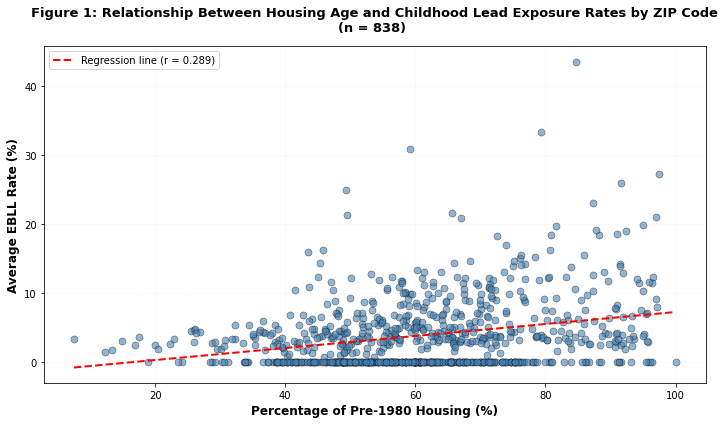

Figure 1: Relationship between pre-1980 housing percentage and childhood EBLL rates in Michigan ZIP codes (n = 838).


In [9]:
plt.figure(figsize=(10, 6))

#Create scatter plot
plt.scatter(
    rq1_data['Pct_Pre1980'],
    rq1_data['EBLL_Pct'],
    alpha=0.6,
    s=50,
    color='steelblue',        
    edgecolors='black',
    linewidths=0.5
)

# Add regression line


z = np.polyfit(rq1_data['Pct_Pre1980'], rq1_data['EBLL_Pct'], 1)
p_fit = np.poly1d(z)
x_line = np.linspace(rq1_data['Pct_Pre1980'].min(), 
                     rq1_data['Pct_Pre1980'].max(), 100)
plt.plot(x_line, p_fit(x_line),    
         color='red', 
         linestyle='--', 
         linewidth=2,
         label=f'Regression line (r = {r_main:.3f})')

# Labels and title
plt.xlabel('Percentage of Pre-1980 Housing (%)', fontsize=12, fontweight='bold')
plt.ylabel('Average EBLL Rate (%)', fontsize=12, fontweight='bold')
plt.title('Figure 1: Relationship Between Housing Age and Childhood Lead Exposure Rates by ZIP Code\n' +
          f'(n = {len(rq1_data)}) ',
          fontsize=13, fontweight='bold', pad=15)

plt.legend(loc='best', fontsize=10)

plt.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)



plt.tight_layout()

plt.savefig('Figure1_RQ1_Scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 1: Relationship between pre-1980 housing percentage and childhood EBLL rates in Michigan ZIP codes (n = 838).')

## 2.3 Visualization 2: Bar Chart



Mean EBLL Rate by Housing Category:
  Low (<40%): 2.09% (SE=0.21, SD=1.86, n=78)
  Medium (40-70%): 3.15% (SE=0.19, SD=4.25, n=519)
  High (≥70%): 5.91% (SE=0.42, SD=6.45, n=241)


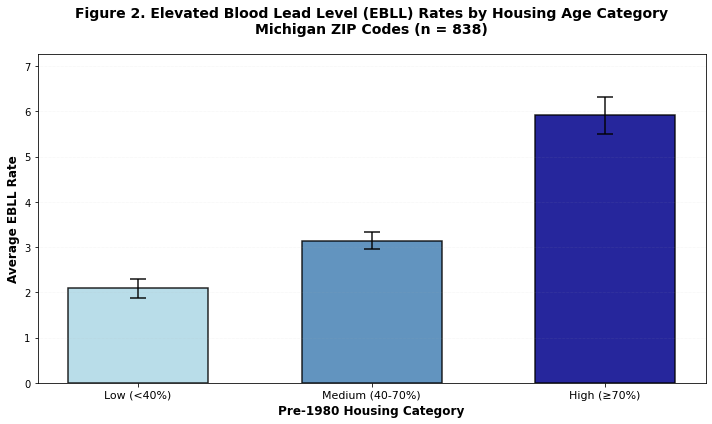

Figure 2: Average EBLL rates by housing age category. Error bars represent standard error.


In [10]:
# Calculate statistics by housing category
category_stats = rq1_data.groupby('Housing_Category')['EBLL_Pct'].agg([
    'mean', 'std', 'count'
]).reset_index()
category_stats.columns = ['Housing_Category', 'Mean_EBLL', 'Std_EBLL', 'Count']

# Calculate standard error
category_stats['SE_EBLL'] = category_stats['Std_EBLL'] / np.sqrt(category_stats['Count'])

# Define category order
category_order = ['Low (<40%)', 'Medium (40-70%)', 'High (≥70%)']
category_stats['Housing_Category'] = pd.Categorical(
    category_stats['Housing_Category'],
    categories=category_order,
    ordered=True
)
category_stats = category_stats.sort_values('Housing_Category')

# Display statistics
print("\nMean EBLL Rate by Housing Category:")
for _, row in category_stats.iterrows():
    print(f"  {row['Housing_Category']}: {row['Mean_EBLL']:.2f}% "
          f"(SE={row['SE_EBLL']:.2f}, SD={row['Std_EBLL']:.2f}, n={int(row['Count'])})")

# Create figure
plt.figure(figsize=(10, 6))

# Create bars with color gradient
colors = ['#ADD8E6', '#4682B4', '#00008B']  # Light blue to dark blue
bars = plt.bar(
    range(len(category_stats)),
    category_stats['Mean_EBLL'],
    color=colors,
    edgecolor='black',
    linewidth=1.5,
    alpha=0.85,
    width=0.6
)

# Add error bars (standard error)
plt.errorbar(
    range(len(category_stats)),
    category_stats['Mean_EBLL'],
    yerr=category_stats['SE_EBLL'],  # Changed from Std_EBLL
    fmt='none',
    color='black',
    capsize=8,
    capthick=2,
    alpha=0.7,
    linewidth=2
)

# Set x-axis labels
plt.xticks(range(len(category_stats)), category_stats['Housing_Category'], fontsize=11)

# Labels and title
plt.xlabel('Pre-1980 Housing Category', fontsize=12, fontweight='bold')
plt.ylabel('Average EBLL Rate', fontsize=12, fontweight='bold')
plt.title('Figure 2. Elevated Blood Lead Level (EBLL) Rates by Housing Age Category\n' +
          f'Michigan ZIP Codes (n = {len(rq1_data):,})',
          fontsize=14, fontweight='bold', pad=20)

# Format axes
max_y = (category_stats['Mean_EBLL'] + category_stats['SE_EBLL']).max()  # Changed
plt.ylim(0, max_y * 1.15)
plt.grid(True, alpha=0.3, axis='y', linestyle=':', linewidth=0.5)

# Tight layout
plt.tight_layout()

# Save figure
plt.savefig('Figure2_RQ1_BarChart.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 2: Average EBLL rates by housing age category. Error bars represent standard error.')

## 2.4 Subgroup Analysis


In [11]:
# SUBGROUP ANALYSIS - KRUSKAL-WALLIS TEST

# Separate data into three groups
low_housing = rq1_data[rq1_data['Housing_Category'] == 'Low (<40%)']['EBLL_Pct']
med_housing = rq1_data[rq1_data['Housing_Category'] == 'Medium (40-70%)']['EBLL_Pct']
high_housing = rq1_data[rq1_data['Housing_Category'] == 'High (≥70%)']['EBLL_Pct']

# Perform Kruskal-Wallis test
h_stat, p_kruskal = stats.kruskal(low_housing, med_housing, high_housing)

print("\n" + "="*60)
print("SUBGROUP ANALYSIS - KRUSKAL-WALLIS TEST")
print("="*60)
print(f"H-statistic: {h_stat:.4f}")
print(f"P-value: {p_kruskal:.6f}")
print(f"\nGroup sizes:")
print(f"  Low housing: {len(low_housing)} ZIP codes, Mean EBLL: {low_housing.mean():.2f}%")
print(f"  Medium housing: {len(med_housing)} ZIP codes, Mean EBLL: {med_housing.mean():.2f}%")
print(f"  High housing: {len(high_housing)} ZIP codes, Mean EBLL: {high_housing.mean():.2f}%")

# Interpret result
if p_kruskal < 0.05:
    print(f"\nINTERPRETATION: The Kruskal-Wallis test shows statistically significant ")
    print(f"differences in EBLL rates across housing age categories (p < 0.05).")
    print(f"This confirms that the association between housing age and EBLL rates")
    print(f"holds across different levels of housing age, not just at the extremes.")
else:
    print(f"\nINTERPRETATION: No statistically significant differences in EBLL rates ")
    print(f"were found across housing age categories (p = {p_kruskal:.4f}).")
    print(f"The groups may be more similar than the correlation suggests.")




SUBGROUP ANALYSIS - KRUSKAL-WALLIS TEST
H-statistic: 44.9733
P-value: 0.000000

Group sizes:
  Low housing: 78 ZIP codes, Mean EBLL: 2.09%
  Medium housing: 519 ZIP codes, Mean EBLL: 3.15%
  High housing: 241 ZIP codes, Mean EBLL: 5.91%

INTERPRETATION: The Kruskal-Wallis test shows statistically significant 
differences in EBLL rates across housing age categories (p < 0.05).
This confirms that the association between housing age and EBLL rates
holds across different levels of housing age, not just at the extremes.


## 2.5 Robustness Checks


In [12]:
# ROBUSTNESS CHECK 1: SPEARMAN CORRELATION

r_spearman, p_spearman = spearmanr(rq1_data['Pct_Pre1980'], 
                                   rq1_data['EBLL_Pct'])

print("\n" + "="*60)
print("ROBUSTNESS CHECK 1: ALTERNATIVE CORRELATION METHOD")
print("="*60)
print(f"Original Pearson correlation: r = {r_main:.4f}, p = {p_main:.6f}")
print(f"Spearman correlation:         r = {r_spearman:.4f}, p = {p_spearman:.6f}")

# Check if results are similar
if abs(r_spearman - r_main) < 0.1 and (p_spearman < 0.05) == (p_main < 0.05):
    print(f"\n  ROBUST: Spearman correlation confirms Pearson result.")
    print(f"  Results are consistent across different correlation methods.")
else:
    print(f"\n  SENSITIVE: Spearman correlation differs from Pearson.")
    print(f"  The relationship may not be strictly linear.")




ROBUSTNESS CHECK 1: ALTERNATIVE CORRELATION METHOD
Original Pearson correlation: r = 0.2892, p = 0.000000
Spearman correlation:         r = 0.2511, p = 0.000000

  ROBUST: Spearman correlation confirms Pearson result.
  Results are consistent across different correlation methods.


In [13]:
# ROBUSTNESS CHECK 2: ALTERNATIVE HOUSING THRESHOLD
# Calculate correlation with pre-1970 housing threshold
housing_1970 = housing_raw.copy()
pre1970_cols = ['B25034_008E', 'B25034_009E', 'B25034_010E', 'B25034_011E']
housing_1970['Pre1970_Housing'] = housing_1970[pre1970_cols].sum(axis=1)
housing_1970['Pct_Pre1970'] = (housing_1970['Pre1970_Housing'] / housing_1970['Total_Housing']) * 100
housing_1970 = housing_1970[['ZIP', 'Pct_Pre1970']].dropna()
# Merge with RQ1 data
rq1_robust_1970 = rq1_data.merge(housing_1970, on='ZIP', how='inner')
# Run correlation
r_1970, p_1970 = pearsonr(rq1_robust_1970['Pct_Pre1970'], 
                           rq1_robust_1970['EBLL_Pct'])
print("\n" + "="*70)
print("ROBUSTNESS CHECK 2: ALTERNATIVE HOUSING AGE THRESHOLD")
print("="*70)
print("Testing with pre-1970 housing (vs. pre-1980 baseline)")
print("\nRationale:")
print("  • Lead paint banned federally in 1978")
print("  • Tests if relationship is specific to 1970s-era housing")
print("    or extends to even older, potentially higher-risk stock")
print(f"\nOriginal (Pre-1980): r = {r_main:.4f}, p = {p_main:.6f}, n = {len(rq1_data)}")
print(f"Alternative (Pre-1970): r = {r_1970:.4f}, p = {p_1970:.6f}, n = {len(rq1_robust_1970)}")
print(f"Change in r: {r_1970 - r_main:+.4f} ({((r_1970 - r_main)/r_main)*100:+.1f}%)")
# Interpretation
if abs(r_1970 - r_main) < 0.05:
    print(f"\n  ROBUST: Correlation essentially identical")
    print("  Relationship holds regardless of specific threshold")
elif r_1970 > r_main:
    print(f"\n  ROBUST AND STRONGER: Correlation increases with pre-1970 threshold")
else:
    print(f"\n  ROBUST BUT WEAKER: Correlation decreases slightly")
    print("  Relationship is primarily driven by 1970-1980 era housing")
# Add effect size comparison
diff_in_r_squared = (r_1970**2 - r_main**2)
print(f"\nVariance explained:")
print(f"  Pre-1980: {r_main**2:.1%} of EBLL variation")
print(f"  Pre-1970: {r_1970**2:.1%} of EBLL variation")
print(f"  Difference: {diff_in_r_squared:+.1%}")


ROBUSTNESS CHECK 2: ALTERNATIVE HOUSING AGE THRESHOLD
Testing with pre-1970 housing (vs. pre-1980 baseline)

Rationale:
  • Lead paint banned federally in 1978
  • Tests if relationship is specific to 1970s-era housing
    or extends to even older, potentially higher-risk stock

Original (Pre-1980): r = 0.2892, p = 0.000000, n = 838
Alternative (Pre-1970): r = 0.3359, p = 0.000000, n = 838
Change in r: +0.0467 (+16.1%)

  ROBUST: Correlation essentially identical
  Relationship holds regardless of specific threshold

Variance explained:
  Pre-1980: 8.4% of EBLL variation
  Pre-1970: 11.3% of EBLL variation
  Difference: +2.9%


In [14]:
# ROBUSTNESS CHECK 3: RECENT YEARS ONLY

# Filter to recent years
recent_years = merged[merged['Year'] >= 2021].copy()

# Calculate average EBLL for recent years only
rq1_recent = recent_years.groupby('ZIP').agg({
    'EBLL_Pct': 'mean',
    'Pct_Pre1980': 'first'
}).reset_index()

# Test correlation on recent data
r_recent, p_recent = pearsonr(rq1_recent['Pct_Pre1980'], rq1_recent['EBLL_Pct'])

print("\n" + "="*60)
print("ROBUSTNESS CHECK 3: ALTERNATIVE TIME PERIOD")
print("="*60)
print(f"Original (2010-2023): r = {r_main:.4f}, p = {p_main:.6f}, n = {len(rq1_data)}")
print(f"Recent only (2021-2023): r = {r_recent:.4f}, p = {p_recent:.6f}, n = {len(rq1_recent)}")

# Check if results are similar
if abs(r_recent - r_main) < 0.15 and (p_recent < 0.05) == (p_main < 0.05):
    print(f"\n  ROBUST: Relationship persists in recent years.")
    print(f"  Finding is not just a historical artifact.")
else:
    print(f"\n  SENSITIVE: Recent years show different pattern.")
    print(f"  The relationship may be changing over time.")



ROBUSTNESS CHECK 3: ALTERNATIVE TIME PERIOD
Original (2010-2023): r = 0.2892, p = 0.000000, n = 838
Recent only (2021-2023): r = 0.3689, p = 0.000000, n = 639

  ROBUST: Relationship persists in recent years.
  Finding is not just a historical artifact.


## 2.6 Outlier Sensitivity Analysis


In [15]:
# OUTLIER SENSITIVITY ANALYSIS

# Identify outliers using IQR method
Q1 = rq1_data['EBLL_Pct'].quantile(0.25)  # 25th percentile
Q3 = rq1_data['EBLL_Pct'].quantile(0.75)  # 75th percentile
IQR = Q3 - Q1  # Interquartile range

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = rq1_data[
    (rq1_data['EBLL_Pct'] < lower_bound) | 
    (rq1_data['EBLL_Pct'] > upper_bound)
]

# Create dataset without outliers
rq1_no_outliers = rq1_data[
    (rq1_data['EBLL_Pct'] >= lower_bound) & 
    (rq1_data['EBLL_Pct'] <= upper_bound)
]

# Remove outliers and re-test
r_no_outliers, p_no_outliers = pearsonr(
    rq1_no_outliers['Pct_Pre1980'], 
    rq1_no_outliers['EBLL_Pct']
)

print("\n" + "="*60)
print("OUTLIER SENSITIVITY ANALYSIS")
print("="*60)
print(f"\nOutlier detection (IQR method):")
print(f"  Q1 (25th percentile): {Q1:.2f}%")
print(f"  Q3 (75th percentile): {Q3:.2f}%")
print(f"  IQR: {IQR:.2f}%")
print(f"  Lower bound: {lower_bound:.2f}%")
print(f"  Upper bound: {upper_bound:.2f}%")
print(f"\nOutliers identified: {len(outliers)} ZIP codes ({len(outliers)/len(rq1_data)*100:.1f}%)")

if len(outliers) > 0:
    print(f"\nExtreme outlier ZIP codes:")
    print(outliers[['ZIP', 'EBLL_Pct', 'Pct_Pre1980']].sort_values('EBLL_Pct', ascending=False).head())

print(f"\n{'Original result:':<30} r = {r_main:.4f}, p = {p_main:.6f}, n = {len(rq1_data)}")
print(f"{'Without outliers:':<30} r = {r_no_outliers:.4f}, p = {p_no_outliers:.6f}, n = {len(rq1_no_outliers)}")
print(f"{'Change in r:':<30} {r_no_outliers - r_main:+.4f}")

# Assess sensitivity
if abs(r_no_outliers - r_main) < 0.1 and (p_no_outliers < 0.05) == (p_main < 0.05):
    print(f"\n  ROBUST: Results remain similar after removing outliers.")
    print(f"  The relationship is not driven by extreme values.")
else:
    print(f"\n  SENSITIVE: Results change substantially without outliers.")
    print(f"  The relationship may be influenced by extreme ZIP codes.")




OUTLIER SENSITIVITY ANALYSIS

Outlier detection (IQR method):
  Q1 (25th percentile): 0.00%
  Q3 (75th percentile): 5.74%
  IQR: 5.74%
  Lower bound: -8.61%
  Upper bound: 14.34%

Outliers identified: 29 ZIP codes (3.5%)

Extreme outlier ZIP codes:
       ZIP   EBLL_Pct  Pct_Pre1980
584  49288  43.550000    84.688995
646  49440  33.400000    79.281437
659  49455  30.885714    59.129788
286  48607  27.216667    97.508494
138  48206  25.985714    91.673477

Original result:               r = 0.2892, p = 0.000000, n = 838
Without outliers:              r = 0.2421, p = 0.000000, n = 809
Change in r:                   -0.0471

  ROBUST: Results remain similar after removing outliers.
  The relationship is not driven by extreme values.


## 1.6 Key Summary of Findings
**Main Finding:**
- Correlation coefficient (r): 0.2892
- P-value: 0.000000 (p < 0.001)
- Interpretation: Statistically significant positive weak-to-moderate correlation

**Subgroup Analysis (Kruskal-Wallis):**
- H-statistic: 44.9733
- P-value: 0.000000 (p < 0.001)
- Low housing (<40%): Mean EBLL = 2.09% (78 ZIP codes)
- Medium housing (40-70%): Mean EBLL = 3.15% (519 ZIP codes)
- High housing (≥70%): Mean EBLL = 5.91% (241 ZIP codes)

**Robustness Check Results:**
1. Spearman correlation: r = 0.2511, p = 0.000000 --> ROBUST
2. Pre-1970 housing: r = 0.3359, p = 0.000000 --> ROBUST
3. Recent years (2021-2023): r = 0.3689, p = 0.000000  --> ROBUST

**Outlier Sensitivity:**
- 29 outliers identified (3.5% of data)
- Original: r = 0.2892, p < 0.001
- Without outliers: r = 0.2421, p < 0.001
- Change in r: -0.0471

Verdict:  ROBUST - Results remain similar after removing outliers


---
# 3. RQ2: Testing Volume Analysis

**Research Question:** Are areas in Michigan (ZIP codes) with a higher share of housing built before 1980 seeing higher rates of childhood EBLL testing from 2010 to 2023?

## 3.1 Main Analysis: Calculate Testing Coverage Rate



In [16]:
# Calculate average number of children tested per ZIP code per year
rq2_data = merged.groupby('ZIP').agg({
    'Children_Tested': 'mean',      # Average children tested per year
    'Pct_Pre1980': 'first',          # Housing % (doesn't change by year)
    'Housing_Category': 'first',     # Category (doesn't change by year)
    'Year': 'count'                  # How many years of data we have
}).reset_index()

rq2_data.columns = ['ZIP', 'Avg_Testing_Volume', 'Pct_Pre1980', 
                    'Housing_Category', 'Years_Available']

# Only keep ZIP codes with at least 5 years of data (for stability)
rq2_data = rq2_data[rq2_data['Years_Available'] >= 5].copy()


# MERGE WITH POPULATION DATA (UNDER 6 YEARS)
# Merge with population data
rq2_data = rq2_data.merge(
    population_clean,
    on='ZIP',
    how='left'  # Keep all testing data, even if no population match
)

# Check merge quality
# print(f"  ZIP codes with testing data: {len(rq2_data):,}")
# print(f"  ZIP codes with population data: {rq2_data['Population_Under_6'].notna().sum():,}")
# print(f"  ZIP codes missing population data: {rq2_data['Population_Under_6'].isna().sum():,}")

# Remove ZIP codes without population data
rq2_data = rq2_data.dropna(subset=['Population_Under_6'])

#print(f"  Final RQ2 dataset: {len(rq2_data):,} ZIP codes")

# CALCULATE TESTING COVERAGE RATE (for children under 6)
# Calculate testing coverage rate as percentage
rq2_data['Testing_Coverage_Rate'] = (
    (rq2_data['Avg_Testing_Volume'] / rq2_data['Population_Under_6']) * 100
)

# Handle edge cases where coverage might exceed 100% --> can happen if children move or are tested multiple times)
rq2_data['Testing_Coverage_Rate'] = rq2_data['Testing_Coverage_Rate'].clip(upper=100)

print(f"\nTesting Coverage Rate Statistics (children under 6):")
print(f"  Mean: {rq2_data['Testing_Coverage_Rate'].mean():.2f}%")
print(f"  Median: {rq2_data['Testing_Coverage_Rate'].median():.2f}%")
print(f"  Range: {rq2_data['Testing_Coverage_Rate'].min():.2f}% - "
      f"{rq2_data['Testing_Coverage_Rate'].max():.2f}%")
print(f"  Std Dev: {rq2_data['Testing_Coverage_Rate'].std():.2f}%")

# Show sample of data for verification
print("\nSample of merged data:")
print(rq2_data[['ZIP', 'Avg_Testing_Volume', 'Population_Under_6', 
                'Testing_Coverage_Rate', 'Pct_Pre1980']].head(10))

# Display summary statistics
print(f"\n{'='*60}")
print(f"RQ2 DATASET SUMMARY")
print(f"{'='*60}")
print(f"Total ZIP codes: {len(rq2_data):,}")
print(f"Pre-1980 housing range: {rq2_data['Pct_Pre1980'].min():.1f}% - "
      f"{rq2_data['Pct_Pre1980'].max():.1f}%")
print(f"Mean pre-1980 housing: {rq2_data['Pct_Pre1980'].mean():.1f}%")
print(f"Average years of data per ZIP: {rq2_data['Years_Available'].mean():.1f} years")


Testing Coverage Rate Statistics (children under 6):
  Mean: 23.05%
  Median: 20.26%
  Range: 5.17% - 100.00%
  Std Dev: 13.14%

Sample of merged data:
     ZIP  Avg_Testing_Volume  Population_Under_6  Testing_Coverage_Rate  \
0  48001          148.285714                 851              17.424878   
1  48002           21.500000                 139              15.467626   
2  48005           35.500000                 201              17.661692   
3  48006           31.600000                 243              13.004115   
4  48015          116.500000                 384              30.338542   
5  48021          567.071429                2496              22.719208   
6  48022           22.000000                 101              21.782178   
7  48023           54.000000                 293              18.430034   
8  48027           34.400000                 164              20.975610   
9  48030          273.750000                 651              42.050691   

   Pct_Pre1980  
0   

## 3.2 Main Statistical Test: Pearson Correlation

In [17]:
# Pearson correlation between pre-1980 housing and testing coverage rate
r_testing, p_testing = pearsonr(rq2_data['Pct_Pre1980'],
                                rq2_data['Testing_Coverage_Rate'])

print("\nPearson Correlation Results (RQ2):")
print(f"  Correlation coefficient (r): {r_testing:.4f}")
print(f"  P-value: {p_testing:.6f}")
print(f"  Sample size (n): {len(rq2_data):,} ZIP codes")

# Interpret the result
if p_testing < 0.05:
    direction = "positive" if r_testing > 0 else "negative"
    if abs(r_testing) < 0.3:
        strength = "weak"
    elif abs(r_testing) < 0.5:
        strength = "moderate"
    else:
        strength = "strong"

    print(f"\nINTERPRETATION (RQ2): There is a statistically significant "
          f"{strength} {direction} correlation between the percentage of "
          f"pre-1980 housing and childhood blood lead testing coverage.")
    print("ZIP codes with more pre-1980 housing tend to have "
          f"{direction} testing coverage.")
else:
    print("\nINTERPRETATION (RQ2): No statistically significant correlation was "
          "found between the percentage of pre-1980 housing and childhood "
          f"blood lead testing coverage (p = {p_testing:.4f}).")



Pearson Correlation Results (RQ2):
  Correlation coefficient (r): 0.3474
  P-value: 0.000000
  Sample size (n): 523 ZIP codes

INTERPRETATION (RQ2): There is a statistically significant moderate positive correlation between the percentage of pre-1980 housing and childhood blood lead testing coverage.
ZIP codes with more pre-1980 housing tend to have positive testing coverage.


## 3.3 Visualization 1: Scatter Plot


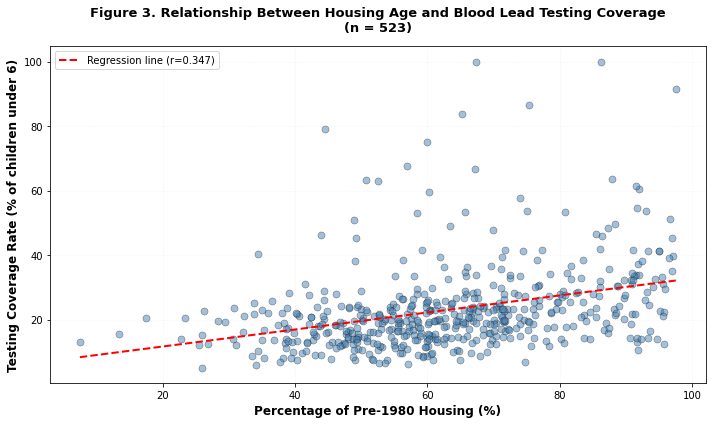

Figure 3: Relationship between pre-1980 housing percentage and EBLL testing rates in Michigan ZIP Codes (n=523).


In [18]:
plt.figure(figsize=(10, 6))

# Create scatter plot
plt.scatter(rq2_data['Pct_Pre1980'], 
            rq2_data['Testing_Coverage_Rate'],
            alpha=0.5, 
            s=50,
            color='steelblue',
            edgecolors='black',
            linewidth=0.5)

# Add regression line
z = np.polyfit(rq2_data['Pct_Pre1980'], rq2_data['Testing_Coverage_Rate'], 1)
p_fit = np.poly1d(z)
x_line = np.linspace(rq2_data['Pct_Pre1980'].min(), 
                     rq2_data['Pct_Pre1980'].max(), 100)
plt.plot(x_line, p_fit(x_line), 
         color='red', 
         linestyle='--', 
         linewidth=2,
         label=f'Regression line (r={r_testing:.3f})')

# Labels and title
plt.xlabel('Percentage of Pre-1980 Housing (%)', fontsize=12, fontweight='bold')
plt.ylabel('Testing Coverage Rate (% of children under 6)', fontsize=12, fontweight='bold')
plt.title('Figure 3. Relationship Between Housing Age and Blood Lead Testing Coverage\n' + 
          f'(n = {len(rq2_data):,})',
          fontsize=13, fontweight='bold', pad=15)

# Add grid
plt.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)

# Legend
plt.legend(loc='best', fontsize=10)

# Format
plt.tight_layout()

# Save figure
plt.savefig('Figure3_RQ2_Scatter.png', dpi=300, bbox_inches='tight')

plt.show()

print('Figure 3: Relationship between pre-1980 housing percentage and EBLL testing rates in Michigan ZIP Codes (n=523).')

## 3.3 Visualization 2: Bar Chart 



Mean Testing Coverage Rate by Housing Category:
  Low (<40%): 16.44% (SE=0.98, SD=6.72, n=47)
  Medium (40-70%): 21.03% (SE=0.72, SD=12.42, n=299)
  High (≥70%): 28.21% (SE=1.05, SD=13.91, n=177)


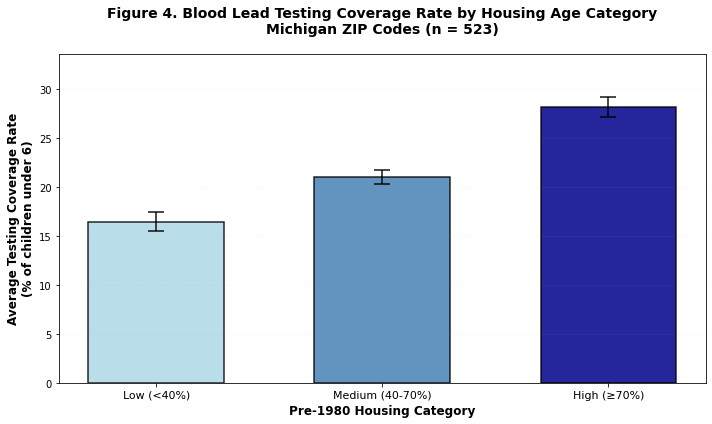

Figure 4: Average EBLL testing coverage rates by housing age category. Error bars represent standard error.


In [19]:
# Calculate statistics by housing category - USE Testing_Coverage_Rate
category_stats = rq2_data.groupby('Housing_Category')['Testing_Coverage_Rate'].agg([
    'mean', 'std', 'count'
]).reset_index()
category_stats.columns = ['Housing_Category', 'Mean_Coverage', 'Std_Coverage', 'Count']

# Calculate standard error
category_stats['SE_Coverage'] = category_stats['Std_Coverage'] / np.sqrt(category_stats['Count'])

# Define category order
category_order = ['Low (<40%)', 'Medium (40-70%)', 'High (≥70%)']
category_stats['Housing_Category'] = pd.Categorical(
    category_stats['Housing_Category'],
    categories=category_order,
    ordered=True
)
category_stats = category_stats.sort_values('Housing_Category')

# Display statistics
print("\nMean Testing Coverage Rate by Housing Category:")
for _, row in category_stats.iterrows():
    print(f"  {row['Housing_Category']}: {row['Mean_Coverage']:.2f}% "
          f"(SE={row['SE_Coverage']:.2f}, SD={row['Std_Coverage']:.2f}, n={int(row['Count'])})")

# Create figure
plt.figure(figsize=(10, 6))

# Create bars with color gradient
colors = ['#ADD8E6', '#4682B4', '#00008B']  # Light blue to dark blue
bars = plt.bar(
    range(len(category_stats)),
    category_stats['Mean_Coverage'],
    color=colors,
    edgecolor='black',
    linewidth=1.5,
    alpha=0.85,
    width=0.6
)

# Add error bars (standard error)
plt.errorbar(
    range(len(category_stats)),
    category_stats['Mean_Coverage'],
    yerr=category_stats['SE_Coverage'],  # Changed from Std_Coverage
    fmt='none',
    color='black',
    capsize=8,
    capthick=2,
    alpha=0.7,
    linewidth=2
)

# Set x-axis labels
plt.xticks(range(len(category_stats)), category_stats['Housing_Category'], fontsize=11)

# Labels and title
plt.xlabel('Pre-1980 Housing Category', fontsize=12, fontweight='bold')
plt.ylabel('Average Testing Coverage Rate\n(% of children under 6)', fontsize=12, fontweight='bold')
plt.title('Figure 4. Blood Lead Testing Coverage Rate by Housing Age Category\n' +
          f'Michigan ZIP Codes (n = {len(rq2_data):,})',
          fontsize=14, fontweight='bold', pad=20)

# Format axes
max_y = (category_stats['Mean_Coverage'] + category_stats['SE_Coverage']).max()  # Changed
plt.ylim(0, max_y * 1.15)
plt.grid(True, alpha=0.3, axis='y', linestyle=':', linewidth=0.5)

# Tight layout
plt.tight_layout()

# Save figure
plt.savefig('Figure4_RQ2_BarChart.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 4: Average EBLL testing coverage rates by housing age category. Error bars represent standard error.')

## 3.4 Subgroup Analysis


In [20]:
# SUBGROUP ANALYSIS - KRUSKAL-WALLIS TEST
# Asking: Do the three housing categories have different testing coverage rates?")

print("\n" + "="*60)
print("SUBGROUP ANALYSIS: KRUSKAL-WALLIS TEST")
print("="*60)

# Separate into groups
low_testing = rq2_data[rq2_data['Housing_Category'] == 'Low (<40%)']['Testing_Coverage_Rate']
med_testing = rq2_data[rq2_data['Housing_Category'] == 'Medium (40-70%)']['Testing_Coverage_Rate']
high_testing = rq2_data[rq2_data['Housing_Category'] == 'High (≥70%)']['Testing_Coverage_Rate']

# Perform test
h_stat_test, p_kruskal_test = stats.kruskal(low_testing, med_testing, high_testing)

print(f"\nH-statistic: {h_stat_test:.4f}")
print(f"P-value: {p_kruskal_test:.6f}")
print(f"\nGroup sizes:")
print(f"  Low housing: {len(low_testing)} ZIP codes, Mean: {low_testing.mean():.2f}%")
print(f"  Medium housing: {len(med_testing)} ZIP codes, Mean: {med_testing.mean():.2f}%")
print(f"  High housing: {len(high_testing)} ZIP codes, Mean: {high_testing.mean():.2f}%")

if p_kruskal_test < 0.05:
    print(f"\n  SIGNIFICANT DIFFERENCE (p < 0.05)")
    print("Testing coverage rates differ significantly across housing age categories.")
else:
    print(f"\n  NO SIGNIFICANT DIFFERENCE (p = {p_kruskal_test:.4f})")
    print("Testing coverage rates are similar across housing age categories.")


SUBGROUP ANALYSIS: KRUSKAL-WALLIS TEST

H-statistic: 74.2467
P-value: 0.000000

Group sizes:
  Low housing: 47 ZIP codes, Mean: 16.44%
  Medium housing: 299 ZIP codes, Mean: 21.03%
  High housing: 177 ZIP codes, Mean: 28.21%

  SIGNIFICANT DIFFERENCE (p < 0.05)
Testing coverage rates differ significantly across housing age categories.


## 3.5 Robustness Checks

In [21]:
# ROBUSTNESS CHECK 1: SPEARMAN CORRELATION

r_spear_test, p_spear_test = spearmanr(rq2_data['Pct_Pre1980'], 
                                       rq2_data['Testing_Coverage_Rate'])

print("\n" + "="*60)
print("ROBUSTNESS CHECK 1: SPEARMAN CORRELATION")
print("="*60)
print("Testing with rank-based correlation (doesn't assume linearity)")
print(f"\nOriginal Pearson: r = {r_testing:.4f}, p = {p_testing:.6f}")
print(f"Spearman rank:    rho = {r_spear_test:.4f}, p = {p_spear_test:.6f}")

if abs(r_spear_test - r_testing) < 0.1:
    print(f"\n  ROBUST: Spearman confirms Pearson result")
    print("  Finding is not dependent on linearity assumption")
else:
    print(f"\n  SENSITIVE: Results differ between methods")
    print("  Relationship may be non-linear")


ROBUSTNESS CHECK 1: SPEARMAN CORRELATION
Testing with rank-based correlation (doesn't assume linearity)

Original Pearson: r = 0.3474, p = 0.000000
Spearman rank:    rho = 0.4197, p = 0.000000

  ROBUST: Spearman confirms Pearson result
  Finding is not dependent on linearity assumption


In [22]:
# ROBUSTNESS CHECK 2: POPULATION SIZE FILTER

# Filter to ZIPs with at least 100 children under 6
# This ensures coverage rates are based on meaningful sample sizes
min_population = 100
rq2_large_pop = rq2_data[rq2_data['Population_Under_6'] >= min_population].copy()

# Re-run correlation with filtered data
r_large, p_large = pearsonr(
    rq2_large_pop['Pct_Pre1980'], 
    rq2_large_pop['Testing_Coverage_Rate']
)

print("\n" + "="*60)
print("ROBUSTNESS CHECK 2: POPULATION SIZE FILTER")
print("="*60)
print(f"Testing with larger populations (≥{min_population} children under 6)")
print("Rationale: Small ZIPs may have unstable coverage rate estimates")

print(f"\nOriginal (all ZIPs):   r = {r_testing:.4f}, p = {p_testing:.6f}, n = {len(rq2_data)}")
print(f"Large populations:     r = {r_large:.4f}, p = {p_large:.6f}, n = {len(rq2_large_pop)}")
print(f"Change in r: {r_large - r_testing:+.4f}")

if abs(r_large - r_testing ) < 0.1 and (p_large < 0.05) == (p_testing < 0.05):
    print(f"\n  ROBUST: Results hold with larger population ZIPs")
    print("  Coverage rates are reliable regardless of ZIP size")
else:
    print(f"\n  SENSITIVE: Results differ with population filter")
    print("  Small ZIPs may have inflated/deflated coverage estimates")

# Additional context
removed = len(rq2_data) - len(rq2_large_pop)
print(f"\nNote: {removed} ZIPs removed (small population)")
print(f"This represents {removed/len(rq2_data)*100:.1f}% of original sample")



ROBUSTNESS CHECK 2: POPULATION SIZE FILTER
Testing with larger populations (≥100 children under 6)
Rationale: Small ZIPs may have unstable coverage rate estimates

Original (all ZIPs):   r = 0.3474, p = 0.000000, n = 523
Large populations:     r = 0.4758, p = 0.000000, n = 453
Change in r: +0.1284

  SENSITIVE: Results differ with population filter
  Small ZIPs may have inflated/deflated coverage estimates

Note: 70 ZIPs removed (small population)
This represents 13.4% of original sample


## 3.6 Outlier Sensitivity Analysis



In [23]:
# OUTLIER SENSITIVITY ANALYSIS 

# Identify outliers using IQR method 
Q1_test = rq2_data['Testing_Coverage_Rate'].quantile(0.25)
Q3_test = rq2_data['Testing_Coverage_Rate'].quantile(0.75)
IQR_test = Q3_test - Q1_test

lower_test = Q1_test - 1.5 * IQR_test
upper_test = Q3_test + 1.5 * IQR_test

outliers_test = rq2_data[
    (rq2_data['Testing_Coverage_Rate'] < lower_test) | 
    (rq2_data['Testing_Coverage_Rate'] > upper_test)
]

# Remove outliers and re-test
rq2_no_outliers = rq2_data[
    (rq2_data['Testing_Coverage_Rate'] >= lower_test) & 
    (rq2_data['Testing_Coverage_Rate'] <= upper_test)
]

r_no_out_test, p_no_out_test = pearsonr(
    rq2_no_outliers['Pct_Pre1980'],
    rq2_no_outliers['Testing_Coverage_Rate']
)

print("\n" + "="*70)
print("OUTLIER SENSITIVITY ANALYSIS")
print("="*70)
print(f"\nOutlier detection (IQR method):")
print(f"  Q1: {Q1_test:.2f}%")
print(f"  Q3: {Q3_test:.2f}%")
print(f"  IQR: {IQR_test:.2f}%")
print(f"  Valid range: {lower_test:.2f}% - {upper_test:.2f}%")

print(f"\nOutliers identified: {len(outliers_test)} ZIP codes ({len(outliers_test)/len(rq2_data)*100:.1f}%)")

if len(outliers_test) > 0:
    print(f"\nExtreme outlier ZIP codes:")
    print(outliers_test[['ZIP', 'Testing_Coverage_Rate', 'Pct_Pre1980']].sort_values(
        'Testing_Coverage_Rate', ascending=False).head())

print(f"\nOriginal:         r = {r_testing:.4f}, p = {p_testing:.6f}, n = {len(rq2_data)}")
print(f"Without outliers: r = {r_no_out_test:.4f}, p = {p_no_out_test:.6f}, n = {len(rq2_no_outliers)}")
print(f"Change in r: {r_no_out_test - r_testing:+.4f}")

if abs(r_no_out_test - r_testing) < 0.1 and (p_no_out_test < 0.05) == (p_testing < 0.05):
    print(f"\n  ROBUST: Results remain similar without outliers")
else:
    print(f"\n  SENSITIVE: Outliers influence the relationship")


OUTLIER SENSITIVITY ANALYSIS

Outlier detection (IQR method):
  Q1: 14.69%
  Q3: 26.55%
  IQR: 11.86%
  Valid range: -3.10% - 44.35%

Outliers identified: 33 ZIP codes (6.3%)

Extreme outlier ZIP codes:
       ZIP  Testing_Coverage_Rate  Pct_Pre1980
284  48878             100.000000    67.282322
266  48841             100.000000    86.246418
202  48607              91.666667    97.508494
521  49963              86.466165    75.320513
352  49130              83.750000    65.205092

Original:         r = 0.3474, p = 0.000000, n = 523
Without outliers: r = 0.4251, p = 0.000000, n = 490
Change in r: +0.0777

  ROBUST: Results remain similar without outliers


## 3.7 RQ2 Key Summary of Findings

**Main Finding:**
- Correlation coefficient (r):  0.3474
- P-value: 0.000000 (p < 0.001)
- Interpretation: Statistically significant positive weak-to-moderate correlation

**Subgroup Analysis (Kruskal-Wallis):**
- H-statistic: 74.2467
- P-value: 0.000000 (p < 0.001)
- Low housing (<40%): Mean EBLL = 16.44% (47 ZIP codes)
- Medium housing (40-70%): Mean EBLL = 21.3% (299 ZIP codes)
- High housing (≥70%): Mean EBLL = 28.21% (177 ZIP codes)

**Robustness Check Results:**
1. Spearman correlation: r = 0.4197, p = 0.000000 --> ROBUST
2. Population size filter: r = 0.4758, p = 0.000000 --> ROBUST

**Outlier Sensitivity:**
- 33 outliers identified (6.3% of data)
- Original: r = 0.3474, p < 0.001
- Without outliers: r = 0.4251, p < 0.001
- Change in r: +0.0777

Verdict:  ROBUST - Results remain similar after removing outliers